In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import warnings

dataset=pd.read_csv("Wine.csv")
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)

In [34]:
encoded_df = pd.get_dummies(dataset,dtype=int,drop_first=True)
print('Wine dataset encoded successfully')
encoded_df

indep_X = encoded_df.iloc[:,:-1].values
featurenames = encoded_df.iloc[:,:-1].columns

dep_Y = encoded_df.iloc[:,-1].values
x_train, x_test, y_train, y_test = train_test_split(indep_X,dep_Y,test_size = 0.2,random_state=0)

Wine dataset encoded successfully


In [35]:
def standardscaler(x_train,x_test):
    sc=StandardScaler()
    x_train = sc.fit_transform(x_train)
    x_test = sc.transform(x_test)
    return x_train,x_test

def lda(x_train,x_test,n):
    lda = LDA(n_components = n)
    x_train = lda.fit_transform(x_train, y_train)
    x_test = lda.transform(x_test)
    featuresindex = np.argmax(np.abs(lda.coef_),axis=1)
    featuresselected = featurenames[featuresindex]
    return x_train,x_test,featuresselected

def cm_prediction(classifier,x_test):
    y_pred = classifier.predict(x_test)
    
    from sklearn.metrics import confusion_matrix
    cm=confusion_matrix(y_test,y_pred)
    
    from sklearn.metrics import accuracy_score
    from sklearn.metrics import classification_report
    Accuracy = accuracy_score(y_test,y_pred)
    report=classification_report(y_test,y_pred)
    return classifier,Accuracy,report,x_test,y_test,cm

def accuracy_table(acclog,accsvml,accknn,accnav,accdes,accrf,accsvmnl,n_components):
    dataframe  = pd.DataFrame(index=[f"Dimensions: {n_components}"],columns=['Logistic','SVMl','SVMnl','KNN','Navie','Decision','Random'])
    for number,idex in enumerate(dataframe.index):      
        dataframe['Logistic'][idex]=acclog[number]       
        dataframe['SVMl'][idex]=accsvml[number]
        dataframe['SVMnl'][idex]=accsvmnl[number]
        dataframe['KNN'][idex]=accknn[number]
        dataframe['Navie'][idex]=accnav[number]
        dataframe['Decision'][idex]=accdes[number]
        dataframe['Random'][idex]=accrf[number]
    return dataframe

def logistic(x_train,y_train,x_test):
    from sklearn.linear_model import LogisticRegression
    classifier = LogisticRegression(random_state = 0)
    classifier.fit(x_train,y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return classifier,Accuracy,report,x_test,y_test,cm

def svm_linear(x_train,y_train,x_test):
    from sklearn.svm import SVC
    classifier = SVC(kernel = 'linear', random_state = 0)
    classifier.fit(x_train, y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return  classifier,Accuracy,report,x_test,y_test,cm

def svm_NL(x_train,y_train,x_test):        
    from sklearn.svm import SVC
    classifier = SVC(kernel = 'rbf', random_state = 0)
    classifier.fit(x_train, y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return  classifier,Accuracy,report,x_test,y_test,cm

def Navie(x_train,y_train,x_test):       
    from sklearn.naive_bayes import GaussianNB
    classifier = GaussianNB()
    classifier.fit(x_train, y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return  classifier,Accuracy,report,x_test,y_test,cm   

def knn(x_train,y_train,x_test):
    from sklearn.neighbors import KNeighborsClassifier
    classifier = KNeighborsClassifier(n_neighbors = 5,metric = "minkowski",p=2)
    classifier.fit(x_train,y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return classifier,Accuracy,report,x_test,y_test,cm

def Decision(x_train,y_train,x_test):
    from sklearn.tree import DecisionTreeClassifier
    classifier = DecisionTreeClassifier(criterion="entropy",random_state=0)
    classifier.fit(x_train,y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return classifier,Accuracy,report,x_test,y_test,cm

def random(x_train,y_train,x_test):
    from sklearn.ensemble import RandomForestClassifier
    classifier = RandomForestClassifier(n_estimators=10,criterion="entropy",random_state=0)
    classifier.fit(x_train,y_train)
    classifier,Accuracy,report,x_test,y_test,cm=cm_prediction(classifier,x_test)
    return classifier,Accuracy,report,x_test,y_test,cm

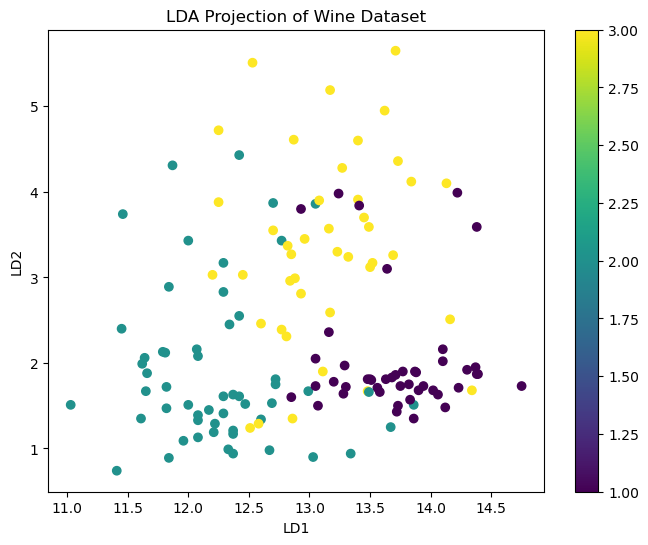

In [36]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c=y_train,
    cmap='viridis'
)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection of Wine Dataset")

plt.colorbar(scatter)

plt.show()

In [37]:
x_train, x_test, y_train, y_test = train_test_split(indep_X,dep_Y,test_size = 0.2,random_state=0)
x_train,x_test = standardscaler(x_train,x_test)
n_components = 1
x_train,x_test,featuresselected = lda(x_train,x_test,n_components);
acclog=[]
accsvml=[]
accsvmnl=[]
accknn=[]
accnav=[]
accdes=[]
accrf=[]
print('LDA transformation completed')

LDA transformation completed


In [38]:
classifier,Accuracy,report,x_test,y_test,cm=logistic(x_train,y_train,x_test)
acclog.append(Accuracy)

classifier,Accuracy,report,x_test,y_test,cm=svm_linear(x_train,y_train,x_test)  
accsvml.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=svm_NL(x_train,y_train,x_test)  
accsvmnl.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=knn(x_train,y_train,x_test)  
accknn.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=Navie(x_train,y_train,x_test)  
accnav.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=Decision(x_train,y_train,x_test)  
accdes.append(Accuracy)
    
classifier,Accuracy,report,x_test,y_test,cm=random(x_train,y_train,x_test)  
accrf.append(Accuracy)

accuracy_table(acclog,accsvmnl,accsvml,accknn,accnav,accdes,accrf,n_components)

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
Dimensions: 1,0.833333,0.833333,0.861111,0.833333,0.833333,0.833333,0.888889
